# Bài tập 1 - bank.csv


Install libraries

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import data

In [11]:
df = pd.read_csv('Lab1_Ex1_bank.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Phân bố dữ liệu
Câu 1: Histogram age - Khách hàng tập trung ở độ tuổi nào?

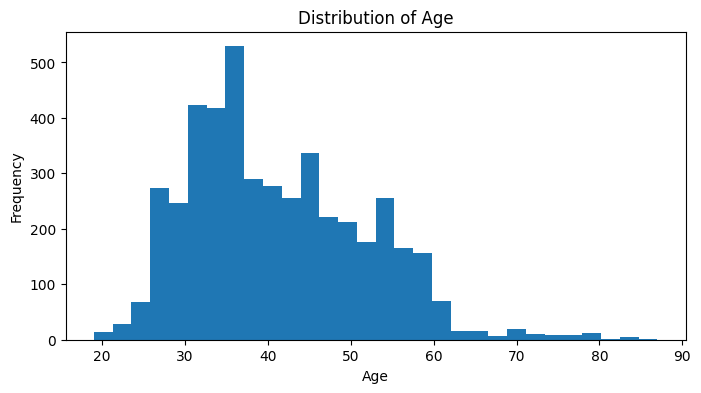

count    4521.000000
mean       41.170095
std        10.576211
min        19.000000
25%        33.000000
50%        39.000000
75%        49.000000
max        87.000000
Name: age, dtype: float64

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()
df['age'].describe()

Câu 2: Histogram balance - Có nhiều giá trị ngoại lai không?

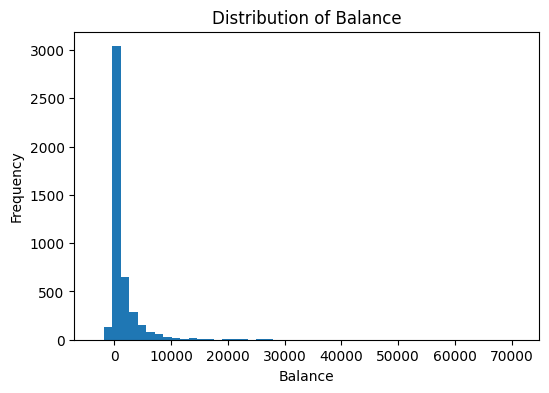

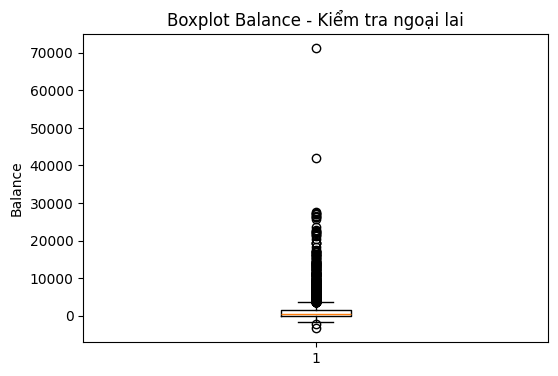

Q1: 69.0 | Q3: 1480.0 | IQR: 1411.0
Số giá trị ngoại lai (IQR): 506 -> Có nhiều ngoại lai không? Có


In [17]:
# Histogram balance
plt.figure(figsize=(6, 4))
plt.hist(df['balance'], bins=50)
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.title('Distribution of Balance')
plt.show()

# Boxplot để nhận diện ngoại lai
plt.figure(figsize=(6, 4))
plt.boxplot(df['balance'])
plt.ylabel('Balance')
plt.title('Boxplot Balance - Kiểm tra ngoại lai')
plt.show()

# IQR: df['balance'].quantile()
q25, q75 = df['balance'].quantile(0.25), df['balance'].quantile(0.75)
iqr = q75 - q25
low, high = q25 - 1.5*iqr, q75 + 1.5*iqr
n_outlier = ((df['balance'] < low) | (df['balance'] > high)).sum()
print('Q1:', q25, '| Q3:', q75, '| IQR:', iqr)
print('Số giá trị ngoại lai (IQR):', n_outlier, '-> Có nhiều ngoại lai không?', 'Có' if n_outlier > 100 else 'Không nhiều')

Câu 3: Biểu đồ cột job - Nghề nào chiếm tỷ lệ cao nhất?

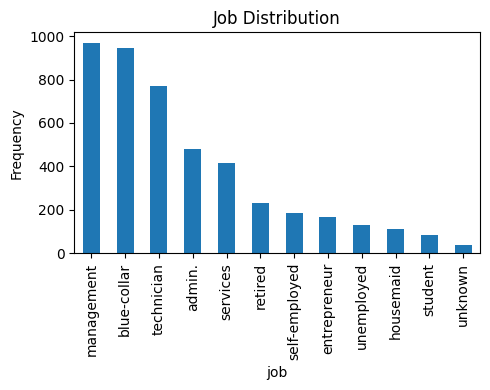

Tỷ lệ: job
management       0.214
blue-collar      0.209
technician       0.170
admin.           0.106
services         0.092
retired          0.051
self-employed    0.040
entrepreneur     0.037
unemployed       0.028
housemaid        0.025
student          0.019
unknown          0.008
Nghề chiếm tỷ lệ cao nhất: management (21.43%)


In [18]:
# df['job'].value_counts().plot(kind='bar')
df['job'].value_counts().plot(kind='bar', figsize=(5, 4))
plt.xlabel('job')
plt.ylabel('Frequency')
plt.title('Job Distribution')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# value_counts(normalize=True) -> tỷ lệ
ratio = df['job'].value_counts(normalize=True)
print('Tỷ lệ:', ratio.round(3).to_string())
print('Nghề chiếm tỷ lệ cao nhất:', ratio.idxmax(), f'({ratio.max():.2%})')

## Quan hệ giữa các biến
Câu 4: Vẽ scatter plot giữa balance và age. Có mối liên hệ nào hay không?

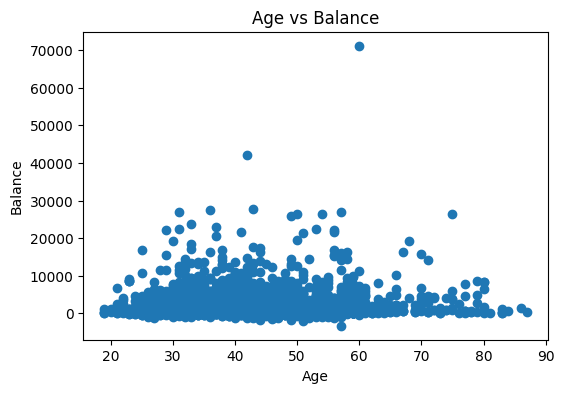

Ma trận tương quan:


,age,balance
age,1.00000,0.08382
balance,0.08382,1.00000


In [22]:
plt.figure(figsize=(6, 4))
plt.scatter(df['age'], df['balance'])
plt.xlabel('Age')
plt.ylabel('Balance')
plt.title('Age vs Balance')
plt.show()
print('Ma trận tương quan:')
df[['age', 'balance']].corr()

Câu 5: Vẽ heatmap ma trận tương quan giữa các thuộc tính

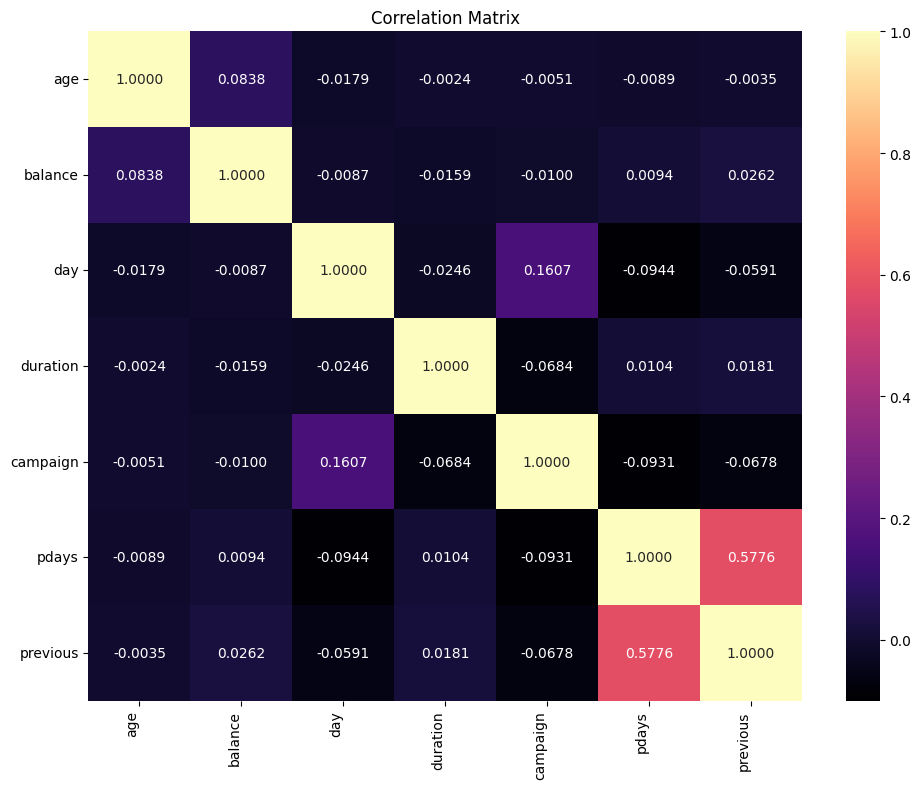

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.4f', cmap='magma', vmin=-0.1, vmax=1)
plt.title('Correlation Matrix')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Câu 6: Số lần liên hệ (campaign) ảnh hưởng thế nào đến kết quả y ?

y            no    yes
campaign              
1         0.862  0.138
2         0.891  0.109
3         0.898  0.102
4         0.868  0.132
5         0.946  0.054
6         0.897  0.103
7         0.920  0.080
8         0.929  0.071
9         0.933  0.067
10        0.963  0.037
11        1.000  0.000
12        0.952  0.048
13        0.882  0.118
14        1.000  0.000
15        1.000  0.000
16        1.000  0.000
17        0.857  0.143
18        1.000  0.000
19        1.000  0.000
20        1.000  0.000
21        1.000  0.000
22        1.000  0.000
23        1.000  0.000
24        0.667  0.333
25        1.000  0.000
28        1.000  0.000
29        1.000  0.000
30        1.000  0.000
31        1.000  0.000
32        1.000  0.000
44        1.000  0.000
50        1.000  0.000


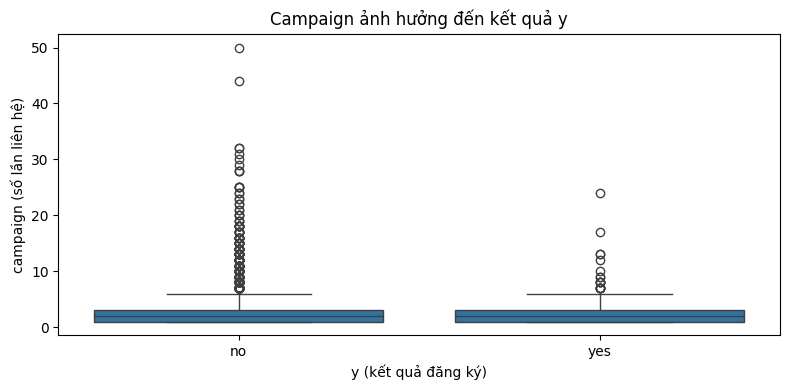

Nhận xét: Số lần liên hệ (campaign) càng cao thì tỷ lệ y=yes thường thấp hơn (khách từ chối nhiều hơn).


In [ ]:
ct = pd.crosstab(df['campaign'], df['y'], normalize='index')
print(ct.round(3))

plt.figure(figsize=(8, 4))
sns.boxplot(x='y', y='campaign', data=df)
plt.xlabel('y (kết quả đăng ký)')
plt.ylabel('campaign (số lần liên hệ)')
plt.title('Campaign ảnh hưởng đến kết quả y')
plt.tight_layout()
plt.show()

if 'yes' in ct.columns:
    print('Nhận xét: Số lần liên hệ (campaign) càng cao thì tỷ lệ y=yes thường thấp hơn (khách từ chối nhiều hơn).')

## Phân tích theo thời gian
Câu 7: Tháng nào có tỷ lệ đăng ký cao nhất?

y            no       yes
month                    
oct    0.537500  0.462500
dec    0.550000  0.450000
mar    0.571429  0.428571
sep    0.673077  0.326923
apr    0.808874  0.191126
feb    0.828829  0.171171
aug    0.875197  0.124803
jan    0.891892  0.108108
jun    0.896422  0.103578
nov    0.899743  0.100257
jul    0.913598  0.086402
may    0.933476  0.066524


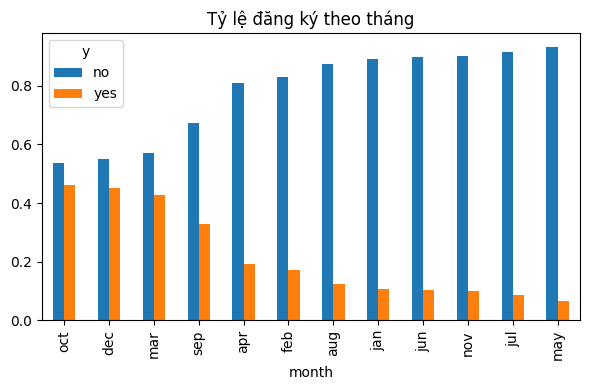

In [35]:
ct = pd.crosstab(df['month'], df['y'], normalize='index')
yes_col = [c for c in ct.columns if 'yes' in str(c).lower()]
if yes_col:
    ct = ct.sort_values(by=yes_col[0], ascending=False)
print(ct)
ct.plot(kind='bar', stacked=False, figsize=(6, 4))
plt.title('Tỷ lệ đăng ký theo tháng')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Câu 8: Thời lượng cuộc gọi trung bình theo từng tháng.

month
apr    294.354949
aug    243.742496
dec    416.900000
feb    255.698198
jan    269.540541
jul    271.205382
jun    252.425612
mar    198.897959
may    267.316166
nov    272.066838
oct    272.800000
sep    215.730769
Name: duration, dtype: float64


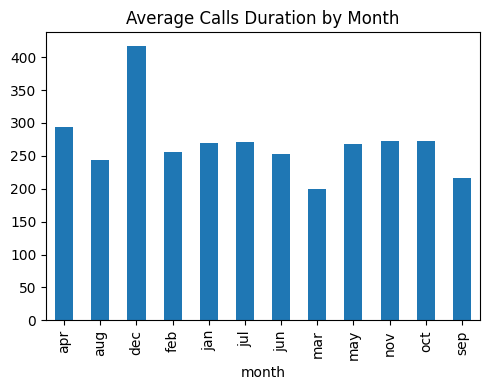

In [41]:
dur_month = df.groupby('month')['duration'].mean()
print(dur_month)
dur_month.plot(kind='bar', figsize=(5, 4))
plt.xlabel('month')
plt.title('Average Calls Duration by Month')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Khám phá dữ liệu (Data Understanding)

Câu 9: Số bản ghi và số thuộc tính

In [ ]:
print('Số bản ghi và số thuộc tính:', df.shape)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


Câu 10: Kiểm tra giá trị thiếu (missing values)

In [ ]:
print('Missing values (NaN):')
print(df.isnull().sum())
print('\nKiểm tra "unknown":')
print(df.eq('unknown').sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Kiểm tra "unknown": df.eq('unknown').sum()
age             0
job            38
marital         0
education     187
default         0
balance         0
housing         0
loan            0
contact      1324
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     3705
y               0
dtype: int64


Câu 11: Biến mục tiêu (target variable) là gì?
- Biến mục tiêu (target variable) là y
- Ý nghĩa: Khách hàng có đăng ký tiền gửi hay không (yes/no)

Câu 12: Có thuộc tính nào có giá trị âm bất thường không? (vd: balance = -88)

In [ ]:
print('Các dòng có balance < 0 (mẫu):')
print(df[df['balance'] < 0][['age', 'balance']].head(10))
print('\nThống kê mô tả:')
df.describe()

Các dòng có balance < 0 (mẫu):
     age  balance
9     43      -88
18    25     -221
48    32     -849
60    41     -516
92    27     -195
123   36     -231
124   51      -55
132   43     -715
138   52     -970
152   45     -249

Thống kê mô tả:


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


## Làm sạch dữ liệu (Data Cleaning)

Câu 13: pdays = -1 có ý nghĩa gì? Có nên thay thế hoặc chuyển thành NaN?

In [46]:
print('pdays = -1 (chưa từng liên hệ):')
print(df['pdays'].value_counts().head())
df_clean = df.copy()
df_clean['pdays'] = df_clean['pdays'].replace(-1, np.nan)

pdays = -1 (chưa từng liên hệ):
pdays
-1      3705
 182      23
 183      20
 92       12
 363      12
Name: count, dtype: int64


Câu 14: Xử lý giá trị "unknown" (contact, poutcome)

In [ ]:
df_clean = df_clean.replace('unknown', np.nan)
for col in ['contact', 'poutcome']:
    if col in df_clean.columns and df_clean[col].isna().any():
        m = df_clean[col].mode()
        df_clean[col] = df_clean[col].fillna(m.iloc[0] if len(m) > 0 else 'cellular')
print('Đã xử lý unknown')

Đã xử lý unknown


Câu 15: Kiểm tra trùng lặp và loại bỏ

In [48]:
print('Số bản ghi trùng:', df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print('Đã xóa trùng. Shape:', df_clean.shape)

Số bản ghi trùng: 0
Đã xóa trùng. Shape: (4521, 17)


Câu 16: Kiểm tra và xử lý ngoại lai (balance, duration) bằng IQR

In [49]:
for col in ['balance', 'duration']:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    print(f'{col}: {n_out} ngoại lai')
    df_clean = df_clean[(df_clean[col] >= low) & (df_clean[col] <= high)]
print('Kích thước sau làm sạch:', df_clean.shape)

balance: 506 ngoại lai
duration: 293 ngoại lai
Kích thước sau làm sạch: (3722, 17)


## Chuyển đổi dữ liệu (Transformation)

Câu 17: Chuẩn hóa age, balance, duration (StandardScaler)

In [51]:
# Import 
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [52]:
df_t = df_clean.copy()
scaler = StandardScaler()
df_t[['age', 'balance', 'duration']] = scaler.fit_transform(df_t[['age', 'balance', 'duration']])
print('Đã chuẩn hóa age, balance, duration')

Đã chuẩn hóa age, balance, duration


Câu 18: Mã hóa biến phân loại (One-hot: job, marital, education; Label: housing, loan)

In [ ]:
for col in ['job', 'marital', 'education']:
    if col in df_t.columns and df_t[col].isna().any():
        m = df_t[col].mode()
        df_t[col] = df_t[col].fillna(m.iloc[0] if len(m) > 0 else 'unknown')
df_t = pd.get_dummies(df_t, columns=['job', 'marital', 'education'], drop_first=True)
le = LabelEncoder()
for c in ['housing', 'loan']:
    if c in df_t.columns:
        df_t[c] = le.fit_transform(df_t[c].astype(str))
print('Đã mã hóa')

Đã mã hóa


Câu 19: Chuyển biến month thành số (1-12)

In [54]:
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
if 'month' in df_t.columns:
    df_t['month_num'] = df_t['month'].astype(str).str.lower().map(month_map)
else:
    df_t['month_num'] = np.nan
print(df_t['month_num'].value_counts().sort_index())

month_num
1      130
2      191
3       37
4      233
5     1183
6      425
7      610
8      527
9       47
10      60
11     268
12      11
Name: count, dtype: int64


## Feature Engineering

Câu 20: Nhóm tuổi (young/middle/senior), Tổng liên hệ (campaign+previous), Đã từng liên hệ (contacted_before)

In [ ]:
df_fe = df_clean.copy()
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 35, 55, 100], labels=['young', 'middle', 'senior'])
df_fe['total_contacts'] = df_fe['campaign'] + df_fe['previous']
df_fe['contacted_before'] = np.where(df_fe['previous'] > 0, 1, 0)
print(df_fe[['age_group', 'total_contacts', 'contacted_before']].head())

  age_group  total_contacts  contacted_before
0     young               1                 0
2     young               2                 1
3     young               4                 0
4    senior               1                 0
5     young               5                 1


Câu 21: duration_per_campaign = duration / campaign

In [56]:
df_fe['duration_per_campaign'] = df_fe['duration'] / df_fe['campaign'].replace(0, np.nan)
print(df_fe['duration_per_campaign'].dropna().head())

0     79.00
2    185.00
3     49.75
4    226.00
5     70.50
Name: duration_per_campaign, dtype: float64


## Phân tích mất cân bằng dữ liệu

Câu 22: Tỷ lệ giữa y = yes và y = no là bao nhiêu ?

y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64


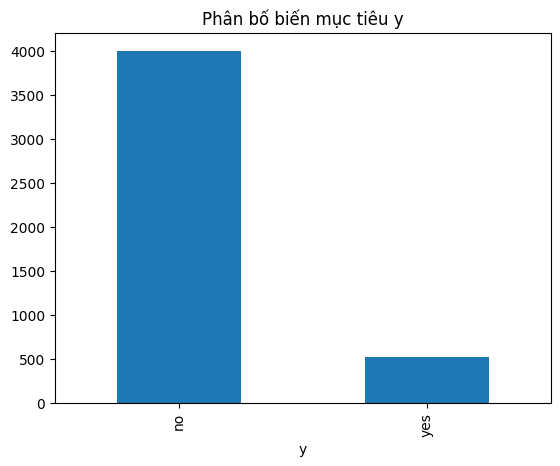

In [57]:
print(df['y'].value_counts(normalize=True))
df['y'].value_counts().plot(kind='bar')
plt.title('Phân bố biến mục tiêu y')
plt.show()

Câu 23: Nếu dữ liệu mất cân bằng, đề xuất phương pháp xử lý (undersampling, oversampling, SMOTE).

Nếu mất cân bằng có thể dùng:
- **RandomOverSampler()** / **RandomUnderSampler()** từ imblearn
- **SMOTE** từ imblearn.over_sampling

Ví dụ:
```python
from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE().fit_resample(X, y)
```

# Bài tập 2 - titanic.csv


Install and import addition library

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import data

In [3]:
df = pd.read_csv('Lab1_Ex2_titanic.csv')
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Phân bố cơ bản
Câu 1: Tỷ lệ sống sót (survived) là bao nhiêu?

In [4]:
print(df['survived'].value_counts(normalize=True))
# df['survived'].value_counts().plot(kind='bar')
# plt.title('Survival rates')
# plt.xticks(rotation=0)
# plt.show()

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64


Câu 2: Phân bố giới tính (sex)

In [6]:
print(df['sex'].value_counts())
# df['sex'].value_counts().plot(kind='bar')
# plt.title('Gender distribution')
# plt.xticks(rotation=0)
# plt.show()

sex
male      843
female    466
Name: count, dtype: int64


Câu 3: Phân bố hạng vé (pclass)


In [7]:
print(df['pclass'].value_counts())
# df['pclass'].value_counts().plot(kind='bar')
# plt.title('Phân bố hạng vé')
# plt.xticks(rotation=0)
# plt.show()

pclass
3    709
1    323
2    277
Name: count, dtype: int64


Câu 4: Phân bố tuổi (age)

count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

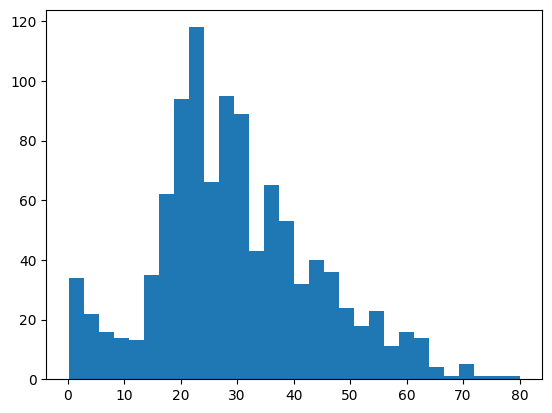

In [8]:
# Gợi ý: Có thể dùng
# plt.hist(df['age'].dropna())
# df['age'].describe()


plt.hist(df['age'].dropna(), bins=30)
# plt.xlabel('Age')
# plt.title('Phân bố tuổi')
# plt.show()
df['age'].describe()

## So sánh theo sống sót
Câu 5: Tỷ lệ sống sót theo giới tính

In [9]:
print(pd.crosstab(df['sex'], df['survived'], normalize='index'))

survived         0         1
sex                         
female    0.272532  0.727468
male      0.809015  0.190985


Câu 6: Tỷ lệ sống sót theo hạng vé (pclass)

In [10]:
print(pd.crosstab(df['pclass'], df['survived'], normalize='index'))

survived         0         1
pclass                      
1         0.380805  0.619195
2         0.570397  0.429603
3         0.744711  0.255289


Câu 7: Tỷ lệ sống sót theo nhóm tuổi

In [11]:
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 60, 100], labels=['child', 'adult', 'senior'])
print(pd.crosstab(df['age_group'], df['survived'], normalize='index'))

survived          0         1
age_group                    
child      0.425532  0.574468
adult      0.602829  0.397171
senior     0.757576  0.242424


Câu 8: Boxplot fare theo survived


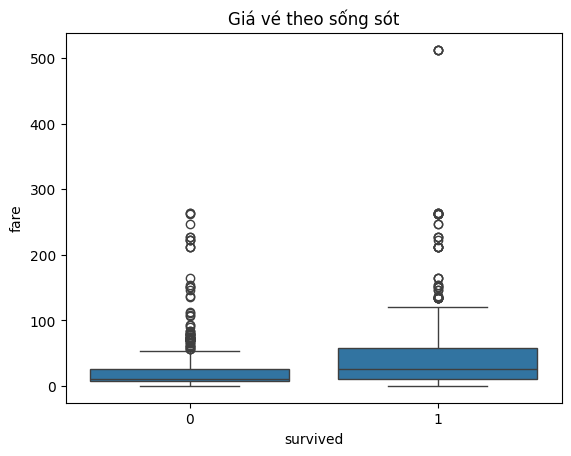

In [12]:
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Giá vé theo sống sót')
plt.show()

## Khám phá dữ liệu
Câu 9: Số dòng và số cột

In [13]:
print('Shape:', df.shape)
df.info()

Shape: (1309, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   int64   
 2   name       1309 non-null   str     
 3   sex        1309 non-null   str     
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   str     
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
 14  age_group  1046 non-null   category
dtypes: category(1), float64(3), int64(4), str(7)
memory usage: 144.7 KB


Câu 10: Ý nghĩa từng biến

In [39]:
# df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   int64   
 2   name       1309 non-null   str     
 3   sex        1309 non-null   str     
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   str     
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
 14  age_group  1046 non-null   category
dtypes: category(1), float64(3), int64(4), str(7)
memory usage: 144.7 KB


Câu 11: Kiểm tra tỷ lệ sống sót (survived) có mất cân bằng không ?

In [15]:
print(df['survived'].value_counts(normalize=True))
print('Có mất cân bằng' if df['survived'].value_counts(normalize=True).min() < 0.3 else 'Tương đối cân bằng')

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64
Tương đối cân bằng


## Làm sạch dữ liệu
Câu 12: Kiểm tra các cột có giá trị thiếu (missing values): age, cabin, embarked, boat, body,
home.dest

In [16]:
cols_missing = ['age', 'cabin', 'embarked', 'boat', 'body', 'home.dest']
missing = df[cols_missing].isnull().sum()
print('Số giá trị thiếu (missing values):')
print(missing)
print('\nTỷ lệ thiếu (%):')
print((missing / len(df) * 100).round(2))

Số giá trị thiếu (missing values):
age           263
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

Tỷ lệ thiếu (%):
age          20.09
cabin        77.46
embarked      0.15
boat         62.87
body         90.76
home.dest    43.09
dtype: float64


Câu 13: Có nên loại bỏ các cột: name, ticket, boat, body. Vì sao?

In [17]:
df_clean = df.drop(columns=['name', 'ticket', 'boat', 'body'], errors='ignore')
print('Đã drop name, ticket, boat, body. Cột còn:', list(df_clean.columns))

Đã drop name, ticket, boat, body. Cột còn: ['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'cabin', 'embarked', 'home.dest', 'age_group']


Câu 14: Xử lý giá trị thiếu ở: age (điền trung bình/trung vị hay theo nhóm giới tính + hạng
vé ?), embarked (điền mode ?)

In [21]:
# age
median_age_by_group = df_clean.groupby(['sex', 'pclass'])['age'].transform('median')
df_clean['age'] = df_clean['age'].fillna(median_age_by_group)
if df_clean['age'].isna().any():
    df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# embarked
embarked_mode = df_clean['embarked'].mode()
if len(embarked_mode) > 0:
    df_clean['embarked'] = df_clean['embarked'].fillna(embarked_mode.iloc[0])

print(df_clean[['age', 'embarked']].isnull().sum())

age         0
embarked    0
dtype: int64


Câu 15: Kiểm tra và xử lý trùng lặp dữ liệu.

In [22]:
n_before = len(df_clean)
n_dup = df_clean.duplicated().sum()
print('Số bản ghi trùng lặp (duplicate):', n_dup)
if n_dup > 0:
    print('Ví dụ vài dòng trùng:')
    print(df_clean[df_clean.duplicated(keep=False)].sort_values(by=list(df_clean.columns)).head(10))

df_clean = df_clean.drop_duplicates()
n_after = len(df_clean)
print('\nSau khi xóa trùng: shape =', df_clean.shape)

Số bản ghi trùng lặp (duplicate): 133
Ví dụ vài dòng trùng:
     pclass  survived   sex   age  sibsp  parch  fare cabin embarked  \
419       2         0  male  21.0      1      0  11.5   NaN        S   
420       2         0  male  21.0      1      0  11.5   NaN        S   
363       2         0  male  29.5      0      0   0.0   NaN        S   
384       2         0  male  29.5      0      0   0.0   NaN        S   
410       2         0  male  29.5      0      0   0.0   NaN        S   
473       2         0  male  29.5      0      0   0.0   NaN        S   
528       2         0  male  29.5      0      0   0.0   NaN        S   
581       2         0  male  29.5      0      0   0.0   NaN        S   
347       2         0  male  42.0      0      0  13.0   NaN        S   
357       2         0  male  42.0      0      0  13.0   NaN        S   

                 home.dest age_group  
419  Cornwall / Camden, NJ     adult  
420  Cornwall / Camden, NJ     adult  
363                Belfast    

# Chuyển đổi dữ liệu (Transformation)
Câu 16: Mã hóa các biến phân loại: sex, embarked, pclass

Câu 17: Có nên chuẩn hóa các biến: age, fare hay không ? Khi nào cần chuẩn hóa?

- **Có nên:** Có, nếu dùng mô hình nhạy thang đo (KNN, SVM, hồi quy có penalty, neural network).
- **Khi nào:** Khi các biến chênh lệch thang đo lớn (age ~0–80, fare ~0–500+) để tránh biến có giá trị lớn chi phối.

In [ ]:
# import addition library
from sklearn.preprocessing import StandardScaler

In [25]:
cols_scale = ['age', 'fare']
scaler = StandardScaler()
df_encoded[cols_scale] = scaler.fit_transform(df_encoded[cols_scale])
print('Đã chuẩn hóa age, fare (mean≈0, std≈1):')
print(df_encoded[cols_scale].describe().loc[['mean', 'std']])

Đã chuẩn hóa age, fare (mean≈0, std≈1):
               age      fare
mean  2.416812e-17  0.000000
std   1.000425e+00  1.000426


Câu 18: Trích xuất danh xưng (Title) từ cột name (Mr, Mrs, Miss, Master…). Có nên dùng
các danh xưng này làm feature mới không?

In [ ]:
# Trích xuất từ df (gốc) vì df_clean đã bỏ cột name ở Câu 13
title = df['name'].str.extract(r',\s*([A-Za-z]+)\.', expand=False)
print('Phân bố danh xưng (value_counts):')
print(title.value_counts())

# Thêm vào df_clean (cùng index) để dùng làm feature
df_clean['title'] = title.reindex(df_clean.index).values
print('\nTỷ lệ sống sót theo title (gợi ý nên dùng làm feature):')
print(df_clean.groupby('title')['survived'].mean().sort_values(ascending=False))

--> **Kết luận:** Nên dùng. Title phản ánh giới tính/độ tuổi/địa vị và tương quan với tỷ lệ sống sót (vd Mrs, Miss cao hơn Mr).

Câu 19: Tạo biến family_size: ``family_size = sibsp + parch + 1``
is_alone (đi một mình hay không)

In [27]:
#import addition library
import numpy as np

In [28]:
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1
df_clean['is_alone'] = np.where(df_clean['family_size'] == 1, 1, 0)
print('family_size:')
print(df_clean['family_size'].value_counts().sort_index())
print('\nis_alone (1 = đi một mình):')
print(df_clean['is_alone'].value_counts())

family_size:
family_size
1     680
2     228
3     155
4      39
5      20
6      25
7      16
8       8
11      5
Name: count, dtype: int64

is_alone (1 = đi một mình):
is_alone
1    680
0    496
Name: count, dtype: int64


Câu 20: Tạo nhóm tuổi: trẻ em, người lớn, người cao tuổi

In [29]:
df_clean['nhom_tuoi'] = pd.cut(df_clean['age'], bins=[0, 12, 60, 100], labels=['trẻ em', 'người lớn', 'người cao tuổi'])
print('Phân bố nhóm tuổi:')
print(df_clean['nhom_tuoi'].value_counts().sort_index())

Phân bố nhóm tuổi:
nhom_tuoi
trẻ em              93
người lớn         1050
người cao tuổi      33
Name: count, dtype: int64


Câu 21: Tạo biến cabin_known (có thông tin cabin hay không)

In [30]:
df_clean['cabin_known'] = np.where(df_clean['cabin'].notna(), 1, 0)
print('cabin_known (1 = có cabin, 0 = không có):')
print(df_clean['cabin_known'].value_counts())

cabin_known (1 = có cabin, 0 = không có):
cabin_known
0    881
1    295
Name: count, dtype: int64


Câu 22: Tạo biến ``fare_per_person = fare / family_size``

In [ ]:
df_clean['fare_per_person'] = df_clean['fare'] / df_clean['family_size']
print('fare_per_person (vài giá trị đầu):')
print(df_clean['fare_per_person'].head(10))

# Phân tích ngoại lai, nhiễu (Outliers)
Câu 23: Kiểm tra ngoại lai trong: fare, age

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_clean['fare'], ax=axes[0])
axes[0].set_title('Boxplot fare')
sns.boxplot(y=df_clean['age'], ax=axes[1])
axes[1].set_title('Boxplot age')
plt.tight_layout()
plt.show()

for col in ['fare', 'age']:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    print(f'{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f} -> Số ngoại lai: {n_out}')

Câu 24: Có nên xử lý fare = 0 không?

In [31]:
fare_zero = df_clean[df_clean['fare'] == 0]
n_zero = len(fare_zero)
total = len(df_clean)
pct = n_zero / total * 100 if total > 0 else 0
print('Số bản ghi fare = 0:', n_zero)
print('Tỷ lệ:', f'{pct:.2f}%')
if n_zero > 0:
    print('\nVí dụ các dòng fare=0:')
    print(fare_zero[['pclass', 'fare', 'age', 'survived']].head())

Số bản ghi fare = 0: 12
Tỷ lệ: 1.02%

Ví dụ các dòng fare=0:
     pclass  fare   age  survived
7         1   0.0  39.0         0
70        1   0.0  42.0         0
125       1   0.0  42.0         0
150       1   0.0  40.0         0
170       1   0.0  49.0         1


--> **Kết luận:** Nên xử lý nếu có. fare=0 thường bất thường (vé miễn phí/thiếu dữ liệu); có thể thay bằng trung vị fare theo pclass hoặc toàn cục.

# Bài tập 3 - BDS_TPHCM.csv

In [32]:
df_bds = pd.read_csv('Lab1_Ex3_BDS_TPHCM.csv')
print('Shape:', df_bds.shape)
print('Columns:', list(df_bds.columns))
df_bds[['addressLocality', 'address_old', 'Chiều dài', 'Chiều ngang', 'price_value', 'area']].head()

Shape: (13700, 25)
Columns: ['Phòng ăn', 'Pháp lý', 'addressLocality', 'Số phòng ngủ', 'price_text', 'Chính chủ', 'addressRegion', 'Đường trước nhà', 'description', 'Chiều dài', 'streetAddress', 'Sân thượng', 'Thuộc dự án', 'Hướng', 'title', 'Loại BDS', 'Nhà bếp', 'Chiều ngang', 'price_value', 'area', 'Loại tin', 'Mã tin', 'Chổ để xe hơi', 'Số lầu', 'address_old']


,addressLocality,address_old,Chiều dài,Chiều ngang,price_value,area
0,Xã Cần Giờ,"Đường Lương Văn Nho, Xã Long Hòa, Huyện Cần Gi...",22m,"4,5m",3300000000,95.0
1,Xã Cần Giờ,"Đường Duyên Hải, Xã Long Hòa, Huyện Cần Giờ, H...",15m,10m,20000000000,150.0
2,Xã Cần Giờ,"Đường Thạnh Thới, Xã Long Hòa, Huyện Cần Giờ, ...",120m,100m,192000000000,12.0
3,Xã Cần Giờ,"Đường Nguyễn Văn Mạnh, Xã Long Hòa, Huyện Cần ...",120m,100m,192000000000,12.0
4,Xã Cần Giờ,"Đường Nguyễn Văn Mạnh, Xã Long Hòa, Huyện Cần ...",100m,120m,192000000000,12.0


Yêu cầu 1: Tìm địa chỉ cũ từ addressLocality (đối chiếu address_old). Sau sáp nhập, địa chỉ thay đổi (xã/phường mới). Trích xuất Quận/Huyện cũ từ address_old làm tham chiếu.

In [33]:
import re

def extract_old_district(addr):
    if pd.isna(addr): return None
    s = str(addr).strip()
    m = re.search(r'(Quận\s+\d+|Huyện\s+[^,]+)', s)
    return m.group(1) if m else None

df_bds['quan_huyen_cu'] = df_bds['address_old'].apply(extract_old_district)
print('Ví dụ địa chỉ cũ (Quận/Huyện) trích từ address_old:')
print(df_bds[['addressLocality', 'address_old', 'quan_huyen_cu']].drop_duplicates('addressLocality').head(15))

Ví dụ địa chỉ cũ (Quận/Huyện) trích từ address_old:
       addressLocality                                        address_old  \
0           Xã Cần Giờ  Đường Lương Văn Nho, Xã Long Hòa, Huyện Cần Gi...   
6        Xã Bình Khánh  Đường Tam Thôn Hiệp, Xã Bình Khánh, Huyện Cần ...   
35     Xã An Thới Đông  Đường An Thới Đông, Xã An Thới Đông, Huyện Cần...   
211      Xã Tân An Hội  Tỉnh Lộ 2, Xã Tân An Hội, Huyện Củ Chi, Hồ Chí...   
213          Xã Củ Chi  Đường Trần Tử Bình, Xã Tân Thông Hội, Huyện Củ...   
224         Xã Thái Mỹ   Tỉnh Lộ 7, Xã Thái Mỹ, Huyện Củ Chi, Hồ Chí Minh   
228       Xã Nhuận Đức  Đường Bùi Thị Điệt, Xã Phạm Văn Cội, Huyện Củ ...   
230     Xã An Nhơn Tây   Tỉnh Lộ 10, Xã An Phú, Huyện Củ Chi, Hồ Chí Minh   
238         Xã Bình Mỹ  Đường Võ Văn Bích, Xã Bình Mỹ, Huyện Củ Chi, H...   
249    Xã Phú Hòa Đông  Đường Nguyễn Kim Cương, Xã Tân Thạnh Đông, Huy...   
955         Xã Hóc Môn  Đường Song Hành, Xã Hóc Môn, Huyện Hóc Môn, Hồ...   
956      Xã Đông Thạnh  

Yêu cầu 2: Làm sạch Chiều dài, Chiều ngang, price_value, area & giá VND/m²

In [40]:
def clean_measure(s):
    if pd.isna(s): return np.nan
    s = str(s).replace(',', '.').strip()
    num = re.sub(r'[^0-9.]', '', s)
    try:
        return float(num) if num else np.nan
    except: return np.nan

df_bds['chieu_dai_num'] = df_bds['Chiều dài'].apply(clean_measure)
df_bds['chieu_ngang_num'] = df_bds['Chiều ngang'].apply(clean_measure)
df_bds['price_value'] = pd.to_numeric(df_bds['price_value'], errors='coerce')
df_bds['area'] = pd.to_numeric(df_bds['area'].astype(str).str.replace(',', '.'), errors='coerce')
df_bds['gia_vnd_per_m2'] = np.where(df_bds['area'] > 0, df_bds['price_value'] / df_bds['area'], np.nan)
print('Sau làm sạch - mẫu:')
df_bds[['Chiều dài','chieu_dai_num','Chiều ngang','chieu_ngang_num','price_value','area','gia_vnd_per_m2']].head(10)

Sau làm sạch - mẫu:


,Chiều dài,chieu_dai_num,Chiều ngang,chieu_ngang_num,price_value,area,gia_vnd_per_m2
0,22m,22.0,"4,5m",4.5,3300000000,95.000,3.473684e+07
1,15m,15.0,10m,10.0,20000000000,150.000,1.333333e+08
2,120m,120.0,100m,100.0,192000000000,12.000,1.600000e+10
3,120m,120.0,100m,100.0,192000000000,12.000,1.600000e+10
4,100m,100.0,120m,120.0,192000000000,12.000,1.600000e+10
5,116m,116.0,161m,161.0,238000000000,19.000,1.252632e+10
6,105m,105.0,38m,38.0,33500000000,3.943,8.496069e+09
7,46m,46.0,12m,12.0,37940000000,542.000,7.000000e+07
8,"19,8m",19.8,"11,5m",11.5,11350000000,227.000,5.000000e+07
9,"21,1m",21.1,"6,3m",6.3,7748000000,149.000,5.200000e+07


In [41]:
valid = df_bds['gia_vnd_per_m2'].notna() & (df_bds['area'] > 0) & (df_bds['price_value'] > 0)
df_bds_clean = df_bds[valid].copy()

tb_phuong_moi = df_bds_clean.groupby('addressLocality').agg(gia_tb_vnd_m2=('gia_vnd_per_m2', 'mean'), count=('gia_vnd_per_m2', 'count')).round(0)
tb_quan_cu = df_bds_clean.groupby('quan_huyen_cu').agg(gia_tb_vnd_m2=('gia_vnd_per_m2', 'mean'), count=('gia_vnd_per_m2', 'count')).round(0)
print('Trung bình giá VNĐ/m² theo Xã, phường mới (addressLocality):')
print(tb_phuong_moi.sort_values('gia_tb_vnd_m2', ascending=False).head(15))
print('\nTrung bình giá VNĐ/m² theo Quận/Huyện cũ:')
print(tb_quan_cu.sort_values('gia_tb_vnd_m2', ascending=False).head(15))

Trung bình giá VNĐ/m² theo Xã, phường mới (addressLocality):
                        gia_tb_vnd_m2  count
addressLocality                             
Phường An Khánh          3.393885e+10    220
Phường Bình Quới         2.426572e+10      4
Phường Sài Gòn           1.725201e+10    117
Xã Bình Khánh            1.421705e+10     60
Phường Cầu Ông Lãnh      1.199393e+10    160
Phường Cầu Kiệu          1.152367e+10    334
Xã Cần Giờ               9.783686e+09    106
Phường Xuân Hòa          9.323140e+09    393
Phường Tân Mỹ            9.243296e+09     67
Phường Tây Thạnh         7.305958e+09    160
Phường Tân Phú           7.088297e+09     94
Phường Tam Bình          6.157088e+09     27
Phường Cát Lái           5.661321e+09     20
Phường Thủ Đức           5.507904e+09     57
Phường Đông Hưng Thuận   5.406482e+09     76

Trung bình giá VNĐ/m² theo Quận/Huyện cũ:
                  gia_tb_vnd_m2  count
quan_huyen_cu                         
Huyện Cần Giờ      9.614239e+09    211
Quận 1        

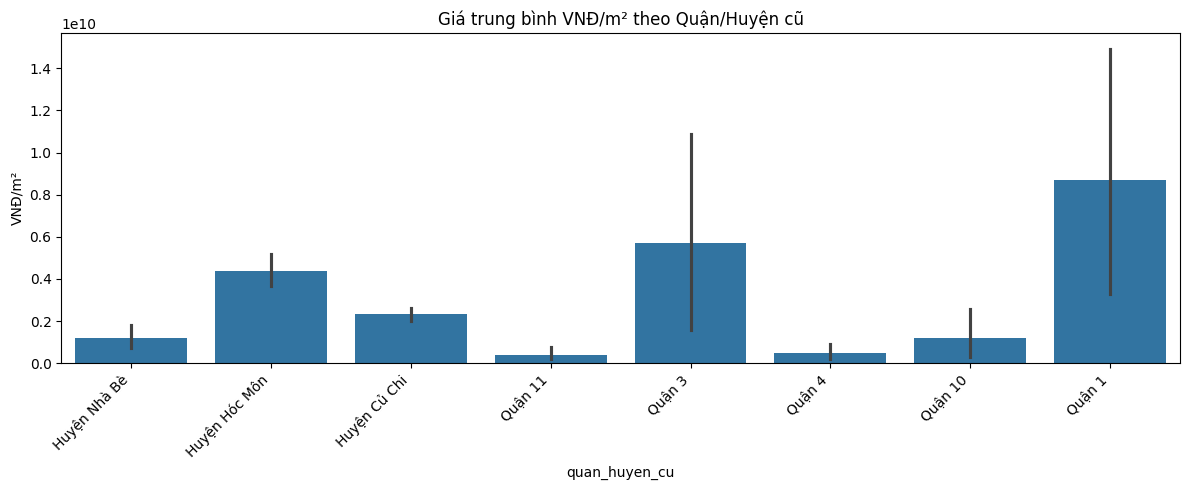

In [42]:
top_quan = df_bds_clean['quan_huyen_cu'].value_counts().head(8).index.tolist()
df_plot = df_bds_clean[df_bds_clean['quan_huyen_cu'].isin(top_quan)]
plt.figure(figsize=(12, 5))
sns.barplot(data=df_plot, x='quan_huyen_cu', y='gia_vnd_per_m2', estimator='mean', order=top_quan)
plt.xticks(rotation=45, ha='right')
plt.title('Giá trung bình VNĐ/m² theo Quận/Huyện cũ')
plt.ylabel('VNĐ/m²')
plt.tight_layout()
plt.show()

### Phân tích ngoại lai (Outliers)

Câu 1: Phát hiện bất động sản có giá quá cao hoặc quá thấp

In [44]:
Q1 = df_bds_clean['gia_vnd_per_m2'].quantile(0.25)
Q3 = df_bds_clean['gia_vnd_per_m2'].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR
outlier_cao = df_bds_clean[df_bds_clean['gia_vnd_per_m2'] > high]
outlier_thap = df_bds_clean[df_bds_clean['gia_vnd_per_m2'] < low]

print('BĐS giá quá cao:', len(outlier_cao))
print('BĐS giá quá thấp:', len(outlier_thap))

BĐS giá quá cao: 1337
BĐS giá quá thấp: 0


Câu 2: Phát hiện diện tích bất thường (ví dụ 12m² nhưng giá 192 tỷ).

In [45]:
# Diện tích rất nhỏ nhưng tổng giá rất cao (vd 12 m², 192 tỷ)
area_nho = 50   # m²
gia_cao_ty = 100  # tỷ VNĐ
bat_thuong = df_bds_clean[(df_bds_clean['area'] < area_nho) & (df_bds_clean['price_value'] > gia_cao_ty * 1e9)].copy()
bat_thuong['price_ty'] = bat_thuong['price_value'] / 1e9
print('Số bản ghi diện tích bất thường (area < {} m² và giá > {} tỷ): {}'.format(area_nho, gia_cao_ty, len(bat_thuong)))
if len(bat_thuong) > 0:
    print(bat_thuong[['addressLocality', 'quan_huyen_cu', 'area', 'price_ty', 'gia_vnd_per_m2']].head(15).to_string())

Số bản ghi diện tích bất thường (area < 50 m² và giá > 100 tỷ): 208
     addressLocality  quan_huyen_cu    area   price_ty  gia_vnd_per_m2
2         Xã Cần Giờ  Huyện Cần Giờ  12.000  192.00000    1.600000e+10
3         Xã Cần Giờ  Huyện Cần Giờ  12.000  192.00000    1.600000e+10
4         Xã Cần Giờ  Huyện Cần Giờ  12.000  192.00000    1.600000e+10
5         Xã Cần Giờ  Huyện Cần Giờ  19.000  238.00000    1.252632e+10
17        Xã Cần Giờ  Huyện Cần Giờ   4.063  101.57500    2.500000e+10
71        Xã Cần Giờ  Huyện Cần Giờ   9.243  277.00000    2.996862e+10
84        Xã Cần Giờ  Huyện Cần Giờ  19.000  238.00000    1.252632e+10
92     Xã Bình Khánh  Huyện Cần Giờ   1.348  990.00003    7.344214e+11
115  Xã An Thới Đông  Huyện Cần Giờ  13.048  110.00000    8.430411e+09
120       Xã Cần Giờ  Huyện Cần Giờ  19.000  238.00000    1.252632e+10
123       Xã Cần Giờ  Huyện Cần Giờ   2.439  134.14500    5.500000e+10
125       Xã Cần Giờ  Huyện Cần Giờ   3.200  128.00000    4.000000e+10
126      

# Trực quan hóa dữ liệu

Câu 3: Vẽ histogram phân bố giá (price_value).

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(df_bds_clean['price_value'] / 1e9, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Giá (tỷ VNĐ)')
plt.ylabel('Số lượng')
plt.title('Histogram phân bố giá (price_value)')
plt.tight_layout()
plt.show()

Câu 4: Vẽ histogram phân bố diện tích (area).

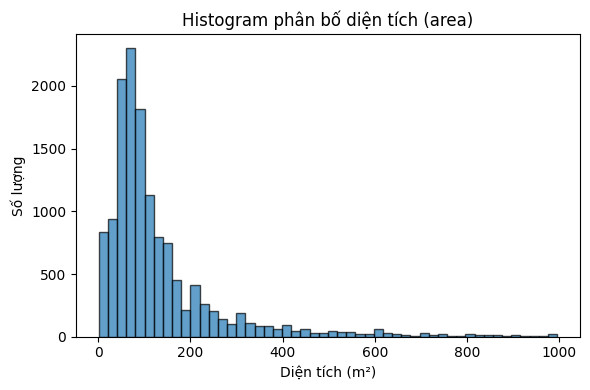

In [47]:
plt.figure(figsize=(6, 4))
plt.hist(df_bds_clean['area'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Diện tích (m²)')
plt.ylabel('Số lượng')
plt.title('Histogram phân bố diện tích (area)')
plt.tight_layout()
plt.show()

Câu 5: So sánh giá trung bình theo từng xã (addressLocality).

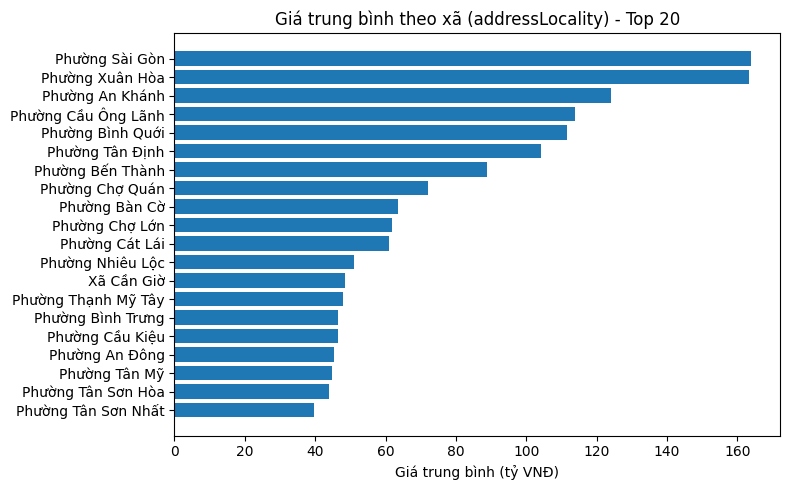

In [53]:
tb_gia_xa = df_bds_clean.groupby('addressLocality')['price_value'].agg(['mean', 'count']).reset_index()
tb_gia_xa.columns = ['addressLocality', 'gia_tb', 'count']
tb_gia_xa['gia_tb_ty'] = tb_gia_xa['gia_tb'] / 1e9
tb_gia_xa = tb_gia_xa.sort_values('gia_tb', ascending=False)
plt.figure(figsize=(8, 5))
top_xa = tb_gia_xa.head(20)
plt.barh(range(len(top_xa)), top_xa['gia_tb_ty'], tick_label=top_xa['addressLocality'])
plt.xlabel('Giá trung bình (tỷ VNĐ)')
plt.title('Giá trung bình theo xã (addressLocality) - Top 20')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Câu 6: So sánh giá/m² theo từng loại BĐS.

Giá trung bình VNĐ/m² theo loại BĐS:
                                     mean  count
Loại BDS                                        
Các loại khác                2.741667e+10      2
Mặt bằng                     1.579205e+10      2
Văn phòng                    1.203520e+10    158
Kho, xưởng                   1.011233e+10    130
Đất thổ cư, đất ở            6.583378e+09   1501
Biệt thự, nhà liền kề        6.115944e+09    515
Đất nông, lâm nghiệp         5.341807e+09    123
Nhà mặt tiền                 5.084201e+09   5143
Nhà hàng, khách sạn          4.145934e+09    115
Đất nền, liền kề, đất dự án  4.088237e+09     81
Phòng trọ, nhà trọ           3.197184e+09    104
Trang trại                   3.131632e+09      6
Nhà trong hẻm                1.792816e+08   5744
Shop, kiot, quán             7.500000e+07      1
Căn hộ chung cư              7.103117e+07     74


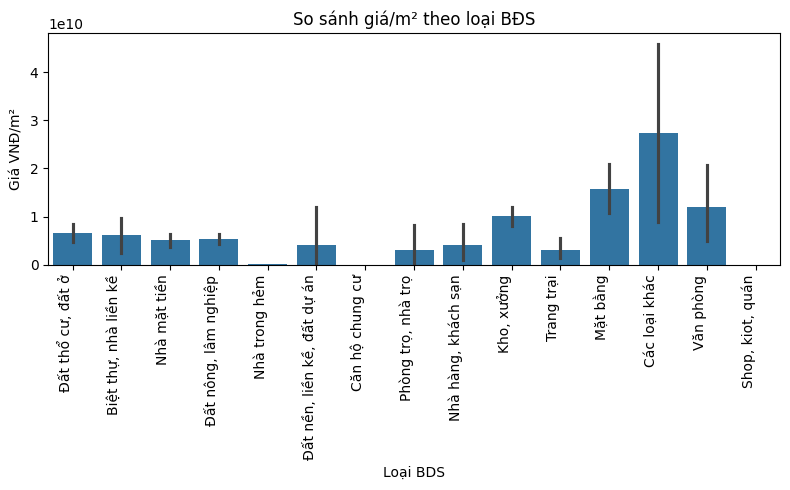

In [54]:
if 'Loại BDS' in df_bds_clean.columns:
    tb_loai = df_bds_clean.groupby('Loại BDS')['gia_vnd_per_m2'].agg(['mean', 'count']).round(0)
    tb_loai = tb_loai.sort_values('mean', ascending=False)
    print('Giá trung bình VNĐ/m² theo loại BĐS:')
    print(tb_loai)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_bds_clean, x='Loại BDS', y='gia_vnd_per_m2', estimator='mean')
    plt.xticks(rotation=90, ha='right')
    plt.ylabel('Giá VNĐ/m²')
    plt.title('So sánh giá/m² theo loại BĐS')
    plt.tight_layout()
    plt.show()
else:
    print('Không có cột Loại BDS')

Câu 7: Vẽ scatter plot giữa diện tích và giá.

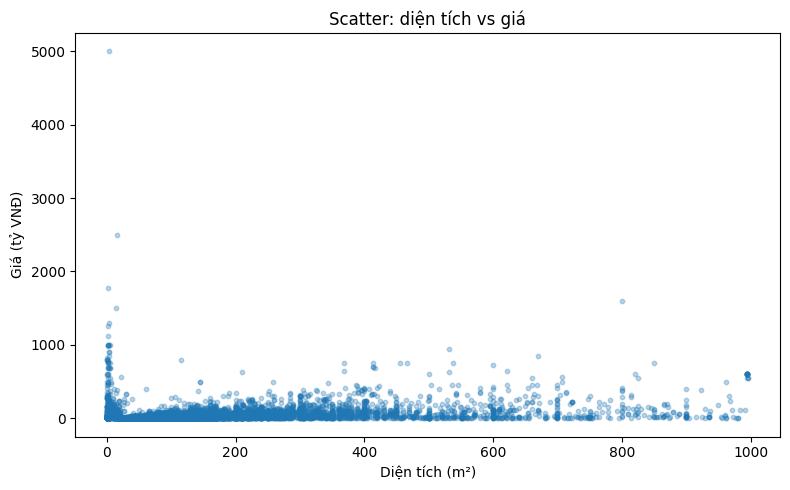

In [57]:
plt.figure(figsize=(8, 5))
plt.scatter(df_bds_clean['area'], df_bds_clean['price_value'] / 1e9, alpha=0.3, s=10)
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá (tỷ VNĐ)')
plt.title('Scatter: diện tích vs giá')
plt.tight_layout()
plt.show()

Câu 8: Vẽ boxplot giá theo loại BĐS.

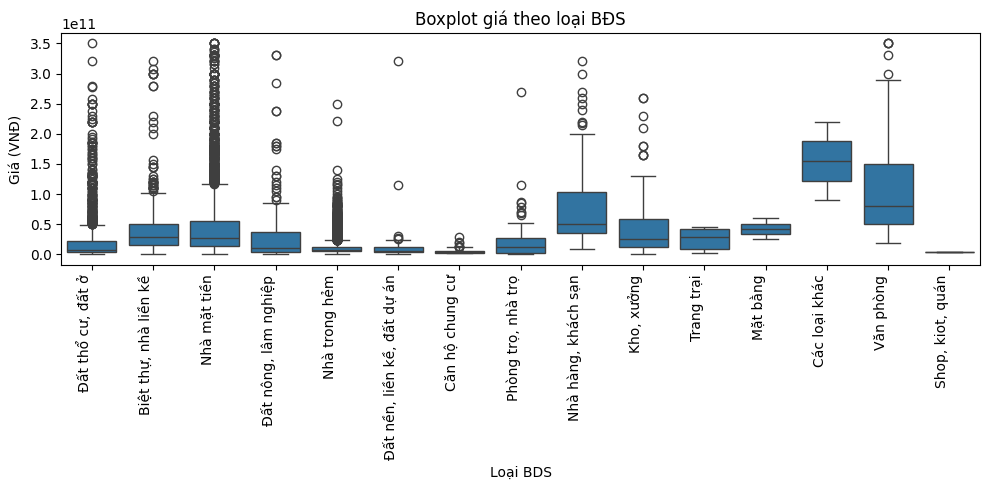

In [61]:
if 'Loại BDS' in df_bds_clean.columns:
    plt.figure(figsize=(10, 5))
    df_plot = df_bds_clean[df_bds_clean['price_value'] < df_bds_clean['price_value'].quantile(0.99)]
    sns.boxplot(data=df_plot, x='Loại BDS', y='price_value')
    plt.xticks(rotation=90, ha='right')
    plt.ylabel('Giá (VNĐ)')
    plt.title('Boxplot giá theo loại BĐS')
    plt.tight_layout()
    plt.show()
else:
    print('Không có cột Loại BDS')

# Khám phá dữ liệu (Data Understanding)

Câu 9: Bộ dữ liệu có bao nhiêu dòng và bao nhiêu cột?

In [62]:
n_dong, n_cot = df_bds.shape[0], df_bds.shape[1]
print('Số dòng:', n_dong)
print('Số cột:', n_cot)

Số dòng: 13700
Số cột: 29


Câu 10: Những cột nào là dạng số (numeric)?

In [63]:
numeric_cols = df_bds.select_dtypes(include=[np.number]).columns.tolist()
print('Cột dạng số:', numeric_cols)

Cột dạng số: ['Phòng ăn', 'Số phòng ngủ', 'Chính chủ', 'Sân thượng', 'Nhà bếp', 'price_value', 'area', 'Mã tin', 'Chổ để xe hơi', 'chieu_dai_num', 'chieu_ngang_num', 'gia_vnd_per_m2']


Câu 11: Những cột nào là dạng phân loại (categorical)?

In [64]:
cat_cols = df_bds.select_dtypes(include=['object', 'category']).columns.tolist()
print('Cột dạng phân loại:', cat_cols)

Cột dạng phân loại: ['Pháp lý', 'addressLocality', 'price_text', 'addressRegion', 'Đường trước nhà', 'description', 'Chiều dài', 'streetAddress', 'Thuộc dự án', 'Hướng', 'title', 'Loại BDS', 'Chiều ngang', 'Loại tin', 'Số lầu', 'address_old', 'quan_huyen_cu']


C:\Users\Tina\AppData\Local\Temp\ipykernel_24168\231828008.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_bds.select_dtypes(include=['object', 'category']).columns.tolist()


Câu 12: Có bao nhiêu tin đăng thuộc từng loại BĐS (Đất thổ cư, Biệt thự, Nhà mặt tiền…)?

In [65]:
if 'Loại BDS' in df_bds.columns:
    dem_loai = df_bds['Loại BDS'].value_counts()
    print('Số tin đăng theo từng loại BĐS:')
    print(dem_loai)
else:
    print('Không có cột Loại BDS')

Số tin đăng theo từng loại BĐS:
Loại BDS
Nhà trong hẻm                  5744
Nhà mặt tiền                   5143
Đất thổ cư, đất ở              1501
Biệt thự, nhà liền kề           515
Văn phòng                       158
Kho, xưởng                      131
Đất nông, lâm nghiệp            123
Nhà hàng, khách sạn             115
Phòng trọ, nhà trọ              104
Đất nền, liền kề, đất dự án      81
Căn hộ chung cư                  74
Trang trại                        6
Mặt bằng                          2
Các loại khác                     2
Shop, kiot, quán                  1
Name: count, dtype: int64


Câu 13: Giá trung bình của bất động sản là bao nhiêu ?

In [66]:
gia_tb = df_bds_clean['price_value'].mean()
print('Giá trung bình (VNĐ):', f'{gia_tb:,.0f}')
print('Giá trung bình (tỷ VNĐ):', f'{gia_tb/1e9:,.2f}')

Giá trung bình (VNĐ): 35,148,018,139
Giá trung bình (tỷ VNĐ): 35.15


# Làm sạch dữ liệu (Data Cleaning)

Câu 14: Kiểm tra các cột có giá trị thiếu (missing values).

In [67]:
missing = df_bds.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Số giá trị thiếu theo cột:')
print(missing)

Số giá trị thiếu theo cột:
Phòng ăn           13700
Chính chủ          13700
Sân thượng         13700
Nhà bếp            13700
Chổ để xe hơi      13700
Thuộc dự án        13529
Hướng              12450
quan_huyen_cu       5008
Pháp lý             3680
Số lầu              2084
chieu_dai_num       2014
Chiều dài           2010
chieu_ngang_num     1817
Chiều ngang         1803
Số phòng ngủ        1730
Đường trước nhà       41
dtype: int64


Câu 15: Chuẩn hóa cột price_text (ví dụ: "3,3 tỷ", "16 triệu/m²") về dạng số.

In [68]:
def parse_price_text(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().replace(',', '.')
    num = re.search(r'([0-9.]+)', s)
    if not num: return np.nan
    x = float(num.group(1))
    if 'tỷ' in s or 'ty' in s.lower(): x *= 1e9
    elif 'triệu' in s or 'trieu' in s.lower(): x *= 1e6
    elif 'nghìn' in s or 'ngan' in s.lower(): x *= 1e3
    return x
df_bds['price_text_num'] = df_bds['price_text'].apply(parse_price_text)
print('Mẫu price_text -> price_text_num:')
print(df_bds[['price_text', 'price_text_num']].drop_duplicates('price_text').head(10))

Mẫu price_text -> price_text_num:
       price_text  price_text_num
0          3,3 tỷ    3.300000e+09
1           20 tỷ    2.000000e+10
2   16 triệu / m²    1.600000e+07
5          238 tỷ    2.380000e+11
6         33,5 tỷ    3.350000e+10
7   70 triệu / m²    7.000000e+07
8   50 triệu / m²    5.000000e+07
9   52 triệu / m²    5.200000e+07
10  40 triệu / m²    4.000000e+07
11   2 triệu / m²    2.000000e+06


Câu 16: Kiểm tra trùng lặp theo Mã tin.

In [69]:
if 'Mã tin' in df_bds.columns:
    dup = df_bds.duplicated(subset=['Mã tin'], keep=False)
    n_dup = dup.sum()
    n_unique = df_bds['Mã tin'].nunique()
    print('Số bản ghi trùng Mã tin:', n_dup)
    print('Số Mã tin duy nhất:', n_unique)
    if n_dup > 0:
        print(df_bds.loc[dup, ['Mã tin', 'price_value', 'addressLocality']].head(10))
else:
    print('Không có cột Mã tin')

Số bản ghi trùng Mã tin: 0
Số Mã tin duy nhất: 13700


Câu 17: Chuẩn hóa các cột có đơn vị "m", "m²" (Chiều dài, Chiều ngang, area).

In [70]:
def to_num_measure(s):
    if pd.isna(s): return np.nan
    s = str(s).replace(',', '.').strip()
    s = re.sub(r'[^0-9.]', '', s)
    try: return float(s) if s else np.nan
    except: return np.nan
df_bds['Chiều dài_num'] = df_bds['Chiều dài'].apply(to_num_measure)
df_bds['Chiều ngang_num'] = df_bds['Chiều ngang'].apply(to_num_measure)
df_bds['area_num'] = pd.to_numeric(df_bds['area'].astype(str).str.replace(',', '.'), errors='coerce')
print('Mẫu sau chuẩn hóa:')
print(df_bds[['Chiều dài', 'Chiều dài_num', 'Chiều ngang', 'Chiều ngang_num', 'area', 'area_num']].head(8))

Mẫu sau chuẩn hóa:
  Chiều dài  Chiều dài_num Chiều ngang  Chiều ngang_num     area  area_num
0       22m           22.0        4,5m              4.5   95.000    95.000
1       15m           15.0         10m             10.0  150.000   150.000
2      120m          120.0        100m            100.0   12.000    12.000
3      120m          120.0        100m            100.0   12.000    12.000
4      100m          100.0        120m            120.0   12.000    12.000
5      116m          116.0        161m            161.0   19.000    19.000
6      105m          105.0         38m             38.0    3.943     3.943
7       46m           46.0         12m             12.0  542.000   542.000
